In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')

tgt_sales = qSales.loc[qSales['tic'] == 'TGT']

display(tgt_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


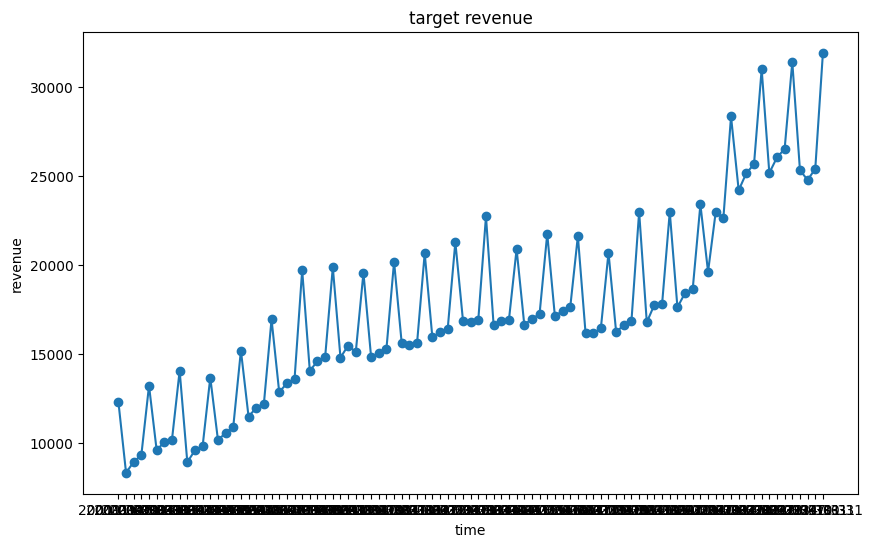

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenue')
plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(tgt_sales['datadate'], tgt_sales['saleq'], marker='o')

In [ ]:
tgt_sales['time'] = range(1, len(tgt_sales) + 1)

# dummy variable 1: holiday season
tgt_sales['holiday_dv'] = np.where(tgt_sales['fqtr'] == 4, 1, 0)

# dummy variable 2: back-to-school season
tgt_sales['bts_dv'] = np.where(tgt_sales['fqtr'] == 3, 1, 0)

display(tgt_sales)

/tmp/ipykernel_1436/4020787062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tgt_sales['time'] = range(1, len(tgt_sales) + 1)
/tmp/ipykernel_1436/4020787062.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tgt_sales['holiday_dv'] = np.where(tgt_sales['fqtr'] == 4, 1, 0)
/tmp/ipykernel_1436/4020787062.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,bts_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,1
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,0
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,1


In [ ]:
dt4training = tgt_sales[:int(0.75*len(tgt_sales))]
dt4testing = tgt_sales[int(0.75*len(tgt_sales)):]

In [ ]:
display(dt4training)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,bts_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,1
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3813,2017-01-31,2016,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2016Q4,2016Q4,20690.00,A,65,1,0
157,3813,2017-04-30,2017,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q1,2017Q1,16223.00,A,66,0,0
158,3813,2017-07-31,2017,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q2,2017Q2,16634.00,A,67,0,0
159,3813,2017-10-31,2017,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q3,2017Q3,16874.00,A,68,0,1


In [ ]:
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,bts_dv
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q1,2018Q1,16781.00,A,70,0,0
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q2,2018Q2,17777.00,A,71,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q3,2018Q3,17821.00,A,72,0,1
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q4,2018Q4,22977.00,A,73,1,0
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q1,2019Q1,17627.00,A,74,0,0
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q2,2019Q2,18422.00,A,75,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q3,2019Q3,18664.00,A,76,0,1
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q4,2019Q4,23399.00,A,77,1,0
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q1,2020Q1,19615.00,A,78,0,0
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q2,2020Q2,22975.00,A,79,0,0


In [ ]:
x = dt4training.loc[:, ['time', 'holiday_dv', 'bts_dv']]
x = sm.add_constant(x)

y = dt4training.loc[:, 'saleq']

model1 = sm.OLS(y, x).fit()

model1.params

,0
const,9270.78
time,139.21
holiday_dv,4599.38
bts_dv,147.49


In [ ]:
print(model_tgt.summary())

                            OLS Regression Results                            
Dep. Variable:                  saleq   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     184.6
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           9.68e-32
Time:                        20:28:47   Log-Likelihood:                -585.47
No. Observations:                  69   AIC:                             1179.
Df Residuals:                      65   BIC:                             1188.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9270.7781    325.997     28.438      0.0

In [ ]:
x_test = dt4testing.loc[:, ['time', 'holiday_dv', 'bts_dv']]
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
161,19015.13
162,19154.34
163,19441.03
164,24032.13
165,19571.95
166,19711.16
167,19997.85
168,24588.95
169,20128.77
170,20267.98


In [ ]:
prediction_results = model1.get_prediction(x_test)
prediction_intervals = prediction_results.summary_frame(alpha=0.2)

display(prediction_intervals)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,19015.13,331.67,18585.72,19444.55,17394.41,20635.86
162,19154.34,337.40,18717.50,19591.18,17531.63,20777.05
163,19441.03,393.40,18931.69,19950.37,17797.32,21084.74
164,24032.13,397.35,23517.67,24546.58,22386.82,25677.43
165,19571.95,354.95,19112.40,20031.51,17942.98,21200.93
166,19711.16,360.90,19243.89,20178.43,18079.99,21342.32
167,19997.85,413.47,19462.52,20533.18,18345.90,21649.80
168,24588.95,418.26,24047.43,25130.47,22934.98,26242.91
169,20128.77,379.05,19638.01,20619.53,18490.72,21766.82
170,20267.98,385.19,19769.27,20766.68,18627.53,21908.43


In [ ]:
# MAPE
y_pred = model_tgt.predict(x_test)
mape = np.mean(np.abs((dt4testing['saleq'].values - y_pred.values) / dt4testing['saleq'].values)) * 100
print(mape)

12.014186519991778


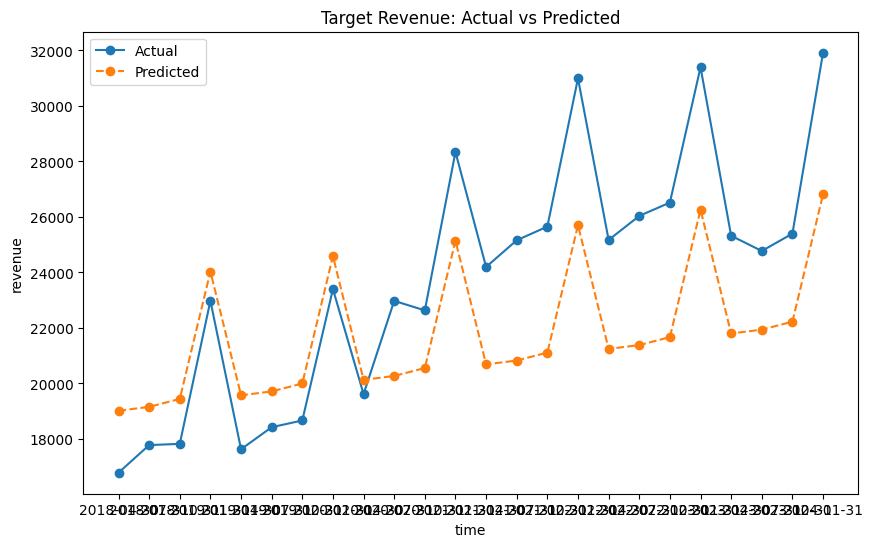

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Target Revenue: Actual vs Predicted')
plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(dt4testing['datadate'].values, dt4testing['saleq'].values, marker='o', label='Actual')
plt.plot(dt4testing['datadate'].values, y_pred.values, marker='o', linestyle='--', label='Predicted')

plt.legend()


To: Chapman Wealth Management

From: QuantFolio Solutions

Date: July 24, 2026

Re: Target Corporation Revenue Analysis


---

###Introduction

A time series OLS regression model for Target Corporation (TGT) achieves a test MAPE of 12.01% and an R² of 0.895. This confirms that Target's revenue follows a highly predictable seasonal pattern.

###Scope

This analysis covers 93 quarters of Target's net revenue from Q4 FY2000 through Q4 FY2023, sourced from qSales_2024.csv. The unit of analysis is one fiscal quarter, and the model was trained on the first 75% of observations (2001-2018) and validated on the remaining 25% (2018-2024).

###Methodology

We used Python via Google Colab for this analysis. OLS regression was estimated using time and two dummy variables as independent variables. Data preparation involved adding a sequential time index and two binary dummy variables derived from the fiscal quarter field. The model equation is: Revenue = 9,270.78 + 139.21 * time + 4,599.38 * holiday_dv + 147.49 * bts_dv.

###Key Findings

1. Holiday dummy variable: Target's Q4 generates approximately 4,599M  more revenye than non-holiday quarters, capturing Black Friday and Christmas shopping surges. This is the strongest seasonal driver in the model and is statistically significant at the 1% level.
2. Back-to-School dummy variable: Target's Q3 generates approximately $147M above baseline, reflecting bts demand for school supplies. However, this variable is not statistically significant (p=0.682), suggesting the effect is modest relative to the overall time trend.
3. The model explains 89.5% of revenue variance with a test MAPE of 12.01%. Forecast errors are concentrated in 2020-2022 where pandemic demand cuased a structural revenue increase not captured by the training data.

###Recommendations

Target's revenue is highly predictable and growing at approximately $139M per quarter, with a reliable holiday premium each Q4. For Chapman Wealth Management, this seasonal consistency is a positive signal, and Q4 performance is the strongest indicator of annual results and should be weighted heavily in any valuation model.